# Can Simple SDEs Describe Equity-Market Time Series? A Mini-Research with Diffusion and Ornstein-Uhlenbeck Benchmarks

**Author:** Dmitri Bolt  
**Course project:** Stochastic Differential Equations

<!-- Русский комментарий: титульная ячейка теперь точнее отражает главный вопрос исследования: можно ли вообще описывать временные ряды фондового рынка через простые SDE-модели и какие именно benchmark-модели для этого разумно брать. Смысл названия согласован с учебной логикой русскоязычного Øksendal: сначала даётся язык SDE, затем он прикладывается к реальным задачам, включая финансовые. См. рус. перевод `TextBooks/Oxendal_B_Stokhasticheskie_differentsialnye_uravnenia.pdf`, вводные главы и финансовые приложения. -->

## 1. Introduction

<!-- Русский комментарий: эта ячейка нужна не просто как общее введение, а как постановка центрального исследовательского вопроса: насколько язык стохастических дифференциальных уравнений вообще подходит для описания stock-market data. По духу это согласовано с русским Øksendal, где подчёркивается связь между теорией случайных процессов и прикладными моделями, в том числе финансовыми. См. рус. перевод `TextBooks/Oxendal_B_Stokhasticheskie_differentsialnye_uravnenia.pdf`, введение и главы 1, 5, 12. -->

This mini-research studies whether stock-market time series can be meaningfully described, at least approximately, by stochastic differential equations.

The notebook uses real equity data to compare several textbook SDE viewpoints with empirical time series: general Itô / diffusion intuition for daily increments, geometric-Brownian-motion-style growth for raw levels, and Ornstein-Uhlenbeck-style mean reversion for detrended levels.

The aim is not to produce a production-grade quantitative model. The aim is to see which simple SDE descriptions remain informative, which ones fail, and how far one can go with transparent empirical diagnostics and small-scale calibration.

## 2. Research objective and scope

<!-- Русский комментарий: эта ячейка формулирует основной вопрос исследования в более точном виде. Главная идея не в том, что “OU meaningful after detrending” само по себе является целью, а в том, что мы проверяем применимость SDE-языка к данным рынка, затем уже уточняем, какой именно тип SDE лучше описывает какой объект. По смыслу это ближе к прикладочной постановке из русскоязычного Øksendal: сначала выбрать математический класс моделей, потом понять, что именно эти модели улавливают в данных, а что нет. См. рус. перевод `TextBooks/Oxendal_B_Stokhasticheskie_differentsialnye_uravnenia.pdf`, главы 1, 5 и финансовые примеры в главе 12. -->

The notebook investigates the following research question:

> **Can stock-market time series be described, even approximately, by stochastic differential equations? If yes, which textbook SDE is more plausible for which empirical object, what rough parameter values arise, and how accurate is the approximation?**

To keep the mini-research focused, the notebook compares two benchmark families rather than the entire space of possible SDEs:

1. **Diffusion / Itô-process intuition** for raw log-prices and raw log-returns.
2. **Ornstein-Uhlenbeck-style mean reversion** for detrended log-prices.

This design deliberately separates two questions:

- whether SDE language is useful at all for market data;
- which transformed time series looks closer to which textbook SDE benchmark.

A working hypothesis tested later is that no single simple SDE describes every aspect of stock-market data equally well: raw trend-dominated levels look closer to GBM-style growth, while detrended levels are more compatible with OU-style mean reversion.

## 3. Short mathematical background

<!-- Русский комментарий: эта ячейка задаёт минимальный теоретический каркас и дальше не должна “висеть в воздухе”. Ниже по notebook формулы из этого раздела будут повторно использоваться как рабочие benchmark-формулы: (4.1.6) — в разделах про increments и diffusion intuition, (5.1.3)–(5.1.5) — в сравнении raw levels с GBM-style growth и в simulation section, (5.7) — в разделах про detrended levels, autocorrelation, OU-style parameter intuition и OU simulation. См. рус. перевод `TextBooks/Oxendal_B_Stokhasticheskie_differentsialnye_uravnenia.pdf`, §2.2 «Важный пример, броуновское движение», теорема 4.1.2, гл. 5.1, упр. 5.7, пример 12.3.5. -->

Following **Definition 2.2.1** in **Chapter 2.2** of Øksendal, **Brownian motion** $B_t$ is the basic noise source used throughout the theory of stochastic differential equations.

Following **Definition 4.1.1** and **Theorem 4.1.2**, an Itô process is introduced in the textbook in integral form as

$$X_t = X_0 + \int_0^t u(s,\omega)\,ds + \int_0^t v(s,\omega)\,dB_s, \tag{4.1.3}$$

and then in shorter differential form as

$$dX_t = u\,dt + v\,dB_t. \tag{4.1.6}$$

In **Chapter 5.1**, Øksendal studies the multiplicative growth model

$$dN_t = rN_t\,dt + \alpha N_t\,dB_t, \tag{5.1.3}$$

whose solution is the geometric Brownian motion

$$N_t = N_0 \exp\!\left(\left(r - \frac{1}{2}\alpha^2\right)t + \alpha B_t\right). \tag{5.1.5}$$

For mean reversion, the notebook takes the textbook OU reference form from **Exercise 5.7**,

$$dX_t = (m - X_t)\,dt + u\,dB_t. \tag{5.7}$$

These formulas are not included only for reference. Later sections will reuse **(4.1.6)** when discussing daily increments, **(5.1.3)**-**(5.1.5)** when comparing raw level growth with GBM-style behavior, and **(5.7)** when interpreting detrended levels and OU-style persistence.

## 4. Data and preprocessing

<!-- Русский комментарий: эта ячейка объясняет, как мы переходим от наблюдаемых рыночных цен к тем эмпирическим объектам, которые затем сопоставляются с SDE-бенчмарками из предыдущего раздела. Важно, что здесь строятся не абстрактные величины, а именно дискретные аналоги тех процессов и приращений, о которых говорит Øksendal: уровни, лог-уровни и приращения лог-уровней. См. рус. перевод `TextBooks/Oxendal_B_Stokhasticheskie_differentsialnye_uravnenia.pdf`, гл. 2.2, гл. 4.1, гл. 5.1. -->

The starting stock universe is taken from `nasdaq_screener_100.csv`. The working download window in this notebook is set to `2023-01-01` - `2026-04-13`, and the actual downloaded panel currently spans from **2023-01-03** to **2026-04-10**.

For each stock $k$ we observe daily close prices $S_{t_i}^k$ on a time grid $t_0 < t_1 < \dots < t_n$. From this raw panel the notebook constructs five related time series:

1. **prices**: the raw close-price series $S_{t_i}^k$.
2. **log-prices**: $X_{t_i}^k = \ln S_{t_i}^k$.
3. **raw log-returns**: $\Delta X_{t_i}^k = X_{t_{i+1}}^k - X_{t_i}^k = \ln\!\left(\frac{S_{t_{i+1}}^k}{S_{t_i}^k}\right)$.
4. **detrended log-prices**: after fitting the linear trend $\widehat{T}_{t_i}^k = \widehat{a}_k + \widehat{b}_k i$, the detrended level is $\widetilde{X}_{t_i}^k = X_{t_i}^k - \widehat{T}_{t_i}^k$.
5. **detrended log-returns**: $\Delta \widetilde{X}_{t_i}^k = \widetilde{X}_{t_{i+1}}^k - \widetilde{X}_{t_i}^k$.

Because the detrending step is linear in time, detrended log-returns differ from raw log-returns mainly by the estimated slope term: $\Delta \widetilde{X}_{t_i}^k = \Delta X_{t_i}^k - \widehat{b}_k$.

These discrete objects are the empirical bridge to the SDE formulas above. Raw log-returns will later play the role of observed one-step increments related to **(4.1.6)**, raw log-prices will be compared with the growth picture from **(5.1.3)**-**(5.1.5)**, and detrended levels will be compared with the mean-reverting picture from **(5.7)**.

In [1]:
import warnings  # Убираю второстепенные warnings, чтобы они не перегружали вывод ноутбука.

import matplotlib.pyplot as plt  # Подключаю базовую библиотеку для графиков.
import numpy as np  # Подключаю численные операции и работу с массивами.
import pandas as pd  # Подключаю таблицы и временные ряды.

from log_returns import LogReturns  # Импортирую основной пайплайн: загрузку цен, логарифмы, доходности и detrending.
from notebook_support import (
    build_ou_validation_diagnostics,  # Импортирую validation diagnostics для OU-style критерия.
    build_representative_diagnostics,  # Импортирую функцию для screening-таблицы representative stocks.
    build_sde_quantitative_summary,  # Импортирую компактную таблицу критериев качества SDE-benchmark.
    compute_autocorrelation_table,  # Импортирую функцию для автокорреляций detrended levels по лагам.
    configure_notebook_style,  # Импортирую функцию для единого стиля графиков в ноутбуке.
    discrete_residual_std_to_ou_diffusion_scale,  # Импортирую перевод дискретного шума в OU diffusion scale.
    display_available_animations,  # Импортирую показ уже готовых GIF-анимаций с диска.
    ensure_animation_assets,  # Импортирую пересборку GIF-анимаций при необходимости.
    fit_simple_ou_parameters,  # Импортирую простую AR(1)-аппроксимацию OU-параметров.
    plot_autocorrelation_table,  # Импортирую график убывания автокорреляции по лагам.
    plot_detrended_levels_with_rolling_mean,  # Импортирую график detrended levels вместе с rolling mean.
    plot_empirical_vs_simulated_ou,  # Импортирую сравнение эмпирической detrended series и OU benchmark.
    plot_raw_vs_detrended,  # Импортирую сравнение raw и detrended levels.
    plot_return_distributions,  # Импортирую сравнение распределений raw и detrended returns.
    plot_rolling_diagnostics,  # Импортирую rolling mean и rolling volatility для raw returns.
    plot_simulated_model_paths,  # Импортирую показ Brownian, GBM и OU траекторий на одном экране.
    simulate_brownian_paths,  # Импортирую симуляцию стандартного броуновского движения.
    simulate_gbm_paths,  # Импортирую симуляцию геометрического броуновского движения.
    simulate_ou_paths,  # Импортирую симуляцию OU-процесса по exact Gaussian transition.
)

warnings.filterwarnings("ignore")  # Прячу шумные предупреждения, чтобы сохранить presentation-friendly output.
configure_notebook_style()  # Применяю единый визуальный стиль ко всем графикам ноутбука.
# Прошу Jupyter показывать matplotlib-графики прямо в ячейках.
%matplotlib inline

In [2]:
df_symbols = pd.read_csv("nasdaq_screener_100.csv")  # Читаю исходный список тикеров из подготовленного NASDAQ screener.
symbols = df_symbols["Symbol"].astype(str).dropna().reset_index(drop=True).tolist()  # Собираю чистый список строковых тикеров для загрузки данных.

# print(f"Number of symbols in the initial universe: {len(symbols)}")  # Показываю размер исходного universe перед фильтрацией и загрузкой.
# symbols[:10]  # Быстро смотрю на первые тикеры, чтобы проверить корректность чтения CSV.

In [3]:
%%capture
# Скрываю служебный вывод загрузки, чтобы ноутбук оставался компактным и не показывал технический шум yfinance.
log_returns_object = LogReturns(  # Создаю основной объект пайплайна для всех дальнейших преобразований данных.
    symbols_local=symbols,
    start_date_local="2023-01-01",
    end_date_local="2026-04-13",
)

prices_df = log_returns_object.get_prices()  # Получаю очищенную панель исходных цен закрытия.
log_prices_df = log_returns_object.get_log_prices()  # Перехожу к log-prices.
log_returns_df = log_returns_object.get_log_returns()  # Строю raw log-returns как первые разности log-prices.
detrended_log_prices_df = log_returns_object.get_detrended_log_prices()  # Удаляю линейный тренд из log-prices.
detrended_returns_df = log_returns_object.get_detrended_log_returns()  # Беру разности уже detrended log-prices.

In [4]:
summary_dict = log_returns_object.get_summary()  # Забираю сводку по качеству данных и по всем этапам preprocessing.
summary_dict["first_available_date"] = prices_df.index.min().strftime("%Y-%m-%d")  # Фиксирую фактическую первую доступную дату после загрузки.
summary_dict["last_available_date"] = prices_df.index.max().strftime("%Y-%m-%d")  # Фиксирую фактическую последнюю доступную дату после загрузки.

summary_df = pd.DataFrame(  # Превращаю словарь summary в удобную табличную форму.
    {"value": list(summary_dict.values())},
    index=list(summary_dict.keys()),
).rename_axis("metric")

# summary_df  # При необходимости могу раскомментировать эту строку, чтобы вывести сводку качества данных.

## 5. Representative stocks

<!-- Русский комментарий: эта ячейка объясняет, почему в учебном notebook разумно перейти от всего universe к нескольким representative examples. Это не означает, что исследовательский вопрос сужается только до этих трёх акций; это означает, что детальные графики нужны как читаемые иллюстрации к общему вопросу о применимости SDE. -->

The full universe is useful for the overall statistical picture, but detailed plots are easier to read when we focus on a few recognizable examples.

Based on a preliminary empirical screening, the notebook starts with the following representative stocks:

- `NVDA`
- `META`
- `GOOG`

Alternative candidates kept in reserve are `AAPL`, `AMZN`, `NFLX`, and `CAT`.

Scientifically, `GOOG` is preferred over `AAPL` because it gives a clearer before/after detrending contrast: the raw log-price trend is stronger, and the detrended oscillations are more visible without becoming too noisy.

The next diagnostic table is shown to make this choice transparent rather than arbitrary.

In [5]:
representative_symbols = ["NVDA", "META", "GOOG"]  # Задаю основной набор тикеров, на которых хочу строить подробные графики.
alternative_symbols = ["AAPL", "AMZN", "NFLX", "CAT"]  # Держу запасных кандидатов для сравнения и возможной замены.

available_representatives = [symbol for symbol in representative_symbols if symbol in prices_df.columns]  # Оставляю только те основные тикеры, которые реально survived после фильтрации данных.
available_alternatives = [symbol for symbol in alternative_symbols if symbol in prices_df.columns]  # Аналогично фильтрую запасных кандидатов по фактической доступности данных.

# print("Representative symbols:", available_representatives)  # При необходимости проверяю, какие основные тикеры доступны в текущем окне.
# print("Alternative candidates:", available_alternatives)  # При необходимости проверяю, какие запасные тикеры доступны в текущем окне.

### Why the next diagnostic table is shown

<!-- Русский комментарий: эта ячейка нужна как методологическое пояснение. Следующая таблица не является “результатом модели”; она нужна для отбора representative stocks. Сравнивать кандидатов надо не по одной колонке, а по комбинации пяти признаков. Логика такая. `raw_trend_r2`: чем больше, тем сильнее raw series похожа на выраженный тренд и тем легче потом обсуждать GBM-style growth. `lag1_autocorr_detrended_level`: чем ближе к 1, тем smoother и более persistent выглядит detrended level, то есть он не распадается в белый шум сразу после detrending. `zero_crossings_detrended_level`: слишком мало пересечений нуля означает почти односторонний drift even after detrending; слишком много пересечений может означать нервный шум, а не плавную mean reversion. `raw_return_std`: показывает, насколько заметны дневные колебания. `detrended_level_std`: показывает амплитуду колебаний после detrending; если она слишком мала, OU-style picture будет плохо видна на графике. Поэтому при выборе тикеров мы ищем не максимум по одной метрике, а разумный компромисс: высокий `raw_trend_r2`, высокий `lag1_autocorr_detrended_level`, не слишком малое число `zero_crossings_detrended_level` и достаточно большую амплитуду (`detrended_level_std`). -->

The next code cell is a **screening step**, not a model-fitting step.

`focus_symbols = available_representatives + available_alternatives` simply collects all candidate tickers that we may want to discuss in the notebook. The function `build_representative_diagnostics(...)` then constructs a compact comparison table for these candidates.

The table reports five quantities, and each one plays a specific role in the stock selection:

- `raw_trend_r2`: the squared correlation between time and the raw log-price. Larger values mean that the raw series is more strongly dominated by a visible trend, which is useful when we later compare raw levels with the GBM-style growth picture.
- `lag1_autocorr_detrended_level`: the lag-1 autocorrelation of the detrended level. Values close to `1` mean that, after detrending, the series still moves smoothly and persistently from one day to the next instead of turning immediately into noisy white fluctuations.
- `zero_crossings_detrended_level`: the number of sign changes of the detrended level around zero. Very small values suggest that even after detrending the series still drifts mostly on one side; larger values indicate more genuine oscillation around the mean level.
- `raw_return_std`: the standard deviation of raw daily log-returns. This measures the day-to-day fluctuation scale of the original series.
- `detrended_level_std`: the standard deviation of the detrended level. Larger values mean that post-detrending oscillations remain visible enough to support an OU-style visual narrative.

So the table is used as a **multi-criteria filter**. A good representative stock should have a strong raw trend, a persistent detrended level, enough zero-crossings to look mean-reverting rather than one-sided, and enough amplitude to remain visually informative after detrending.

In [6]:
focus_symbols = available_representatives + available_alternatives  # Объединяю основные и запасные тикеры в единый список кандидатов для diagnostics.
representative_diagnostics_df = build_representative_diagnostics(  # Считаю компактную screening-таблицу, по которой удобно сравнить кандидатов.
    log_prices_df=log_prices_df,  # Беру raw log-prices, чтобы измерить силу исходного тренда.
    detrended_log_prices_df=detrended_log_prices_df,  # Беру detrended levels, чтобы оценить persistence и zero-crossings вокруг нуля.
    log_returns_df=log_returns_df,  # Беру raw returns, чтобы сравнить дневную volatility кандидатов.
    focus_symbols=focus_symbols,  # Ограничиваю расчёт только теми тикерами, которые хочу обсуждать в ноутбуке.
)

representative_diagnostics_df.round(4)  # Показываю таблицу в округлённом виде, чтобы метрики было легче читать и сравнивать.

,symbol,raw_trend_r2,lag1_autocorr_detrended_level,zero_crossings_detrended_level,raw_return_std,detrended_level_std
0,NVDA,0.8833,0.9916,24,0.0306,0.2362
2,GOOG,0.8663,0.9880,41,0.0187,0.1207
5,NFLX,0.8621,0.9913,32,0.0214,0.1619
6,CAT,0.8370,0.9902,42,0.0188,0.1347
4,AMZN,0.8316,0.9840,46,0.0201,0.1128
1,META,0.8220,0.9919,28,0.0237,0.1867
3,AAPL,0.7818,0.9817,44,0.0160,0.0838


### Reading the screening table

<!-- Русский комментарий: здесь уже нужно показать выбор буквально по цифрам. `NVDA` выбрана потому, что у неё самый высокий `raw_trend_r2 = 0.8833` и одновременно самый высокий `detrended_level_std = 0.2362`; это делает её лучшим “ярким” примером сильного тренда до detrending и большой амплитуды после detrending. `META` выбрана потому, что у неё самый высокий `lag1_autocorr_detrended_level = 0.9919`, а `detrended_level_std = 0.1867` остаётся очень большим; то есть ряд после detrending остаётся очень smooth, но при этом колебания хорошо видны. `GOOG` выбрана прежде всего как более удачный calm-but-expressive example по сравнению с `AAPL`: у `GOOG` `raw_trend_r2 = 0.8663 > 0.7818`, `detrended_level_std = 0.1207 > 0.0838`, `lag1_autocorr_detrended_level = 0.9880 > 0.9817`, а `zero_crossings_detrended_level = 41` против `44` у `AAPL` остаётся достаточно большим. То есть `GOOG` даёт более сильный тренд и более заметные oscillations without losing persistence. Кандидаты `NFLX`, `CAT`, `AMZN` тоже выглядят рабочими, но итоговая тройка выбиралась не как top-3 по одной колонке, а как наиболее удобная и разнородная учебная комбинация: очень яркий пример (`NVDA`), very smooth but still expressive example (`META`), и более спокойный, но всё ещё сильный benchmark-case (`GOOG`). -->

The table is printed here because the choice of representative stocks should be explicit rather than arbitrary.

The selection can be read directly from the numbers.

- `NVDA` is kept because it is the strongest raw-trend example in the shortlist: `raw_trend_r2 = 0.8833`, which is the largest value in the table, and it also has the largest detrended amplitude, `detrended_level_std = 0.2362`. So `NVDA` gives the clearest before/after contrast.
- `META` is kept because it has the highest detrended persistence, `lag1_autocorr_detrended_level = 0.9919`, while its detrended amplitude is still very large, `detrended_level_std = 0.1867`. This makes it a very smooth but still highly visible OU-style example.
- `GOOG` is kept mainly because it dominates `AAPL` on the metrics that matter for the narrative: `raw_trend_r2 = 0.8663 > 0.7818`, `detrended_level_std = 0.1207 > 0.0838`, and `lag1_autocorr_detrended_level = 0.9880 > 0.9817`. So `GOOG` preserves a stronger raw trend and a more visible post-detrending oscillation while remaining highly persistent.

The reserve names are also informative, but they are not used as the final trio for different reasons.

- `NFLX` is numerically strong (`raw_trend_r2 = 0.8621`, `detrended_level_std = 0.1619`), so it remains a valid backup.
- `CAT` and `AMZN` also remain reasonable alternatives, but the final notebook benefits from a cleaner trio built around one extreme-growth example (`NVDA`), one very persistent large-amplitude example (`META`), and one calmer but still strong benchmark (`GOOG`).

So the table is not an end result by itself. It is a transparent numerical justification for the examples used in the rest of the notebook.

## 6. Raw vs detrended comparison

<!-- Русский комментарий: здесь формулы из раздела 3 впервые начинают реально работать как benchmark-language. Теперь мы повторяем их явно, а не только даём ссылки. Для raw levels важна growth-model picture из гл. 5.1: `dN_t = rN_t dt + \alpha N_t dB_t`, а значит `N_t` растёт мультипликативно и `\ln N_t` содержит линейный deterministic trend plus Brownian noise. Для detrended levels важна средне-возвратная формула из упр. 5.7: `dX_t = (m - X_t)dt + u dB_t`. Именно поэтому слева мы смотрим на raw log-prices как на GBM-style object, а справа — на detrended levels как на OU-style object. См. рус. перевод `TextBooks/Oxendal_B_Stokhasticheskie_differentsialnye_uravnenia.pdf`, гл. 5.1 и упр. 5.7. -->

This section gives the first direct link between the textbook formulas in Section 3 and the data.

For raw growth, the benchmark is the geometric Brownian motion model

$$dN_t = rN_t\,dt + \alpha N_t\,dB_t, \tag{5.1.3}$$

with solution

$$N_t = N_0 \exp\!\left(\left(r - \frac{1}{2}\alpha^2\right)t + \alpha B_t\right). \tag{5.1.5}$$

Taking logarithms gives the corresponding log-level picture

$$\ln N_t = \ln N_0 + \left(r - \frac{1}{2}\alpha^2\right)t + \alpha B_t,$$

so the raw log-price is expected to look like a linear growth trend plus Brownian-type random fluctuation.

For mean reversion, the benchmark is the OU-style equation

$$dX_t = (m - X_t)\,dt + u\,dB_t. \tag{5.7}$$

so the level is expected to fluctuate around a long-run mean rather than drift upward persistently.

The raw log-price panels are therefore compared with the GBM-style growth picture, while the detrended panels are compared with the OU-style mean-reverting picture. In the plots below, the left column visualizes the empirical series $X_{t_i}^k = \ln S_{t_i}^k$, and the right column visualizes the detrended series $\widetilde{X}_{t_i}^k = X_{t_i}^k - \widehat{T}_{t_i}^k$. The graph titles and y-axis labels repeat this notation explicitly so that the reader can match each panel with the corresponding formula.

The goal is not to claim exact model fit. The goal is to see which transformed series looks qualitatively closer to which SDE benchmark.

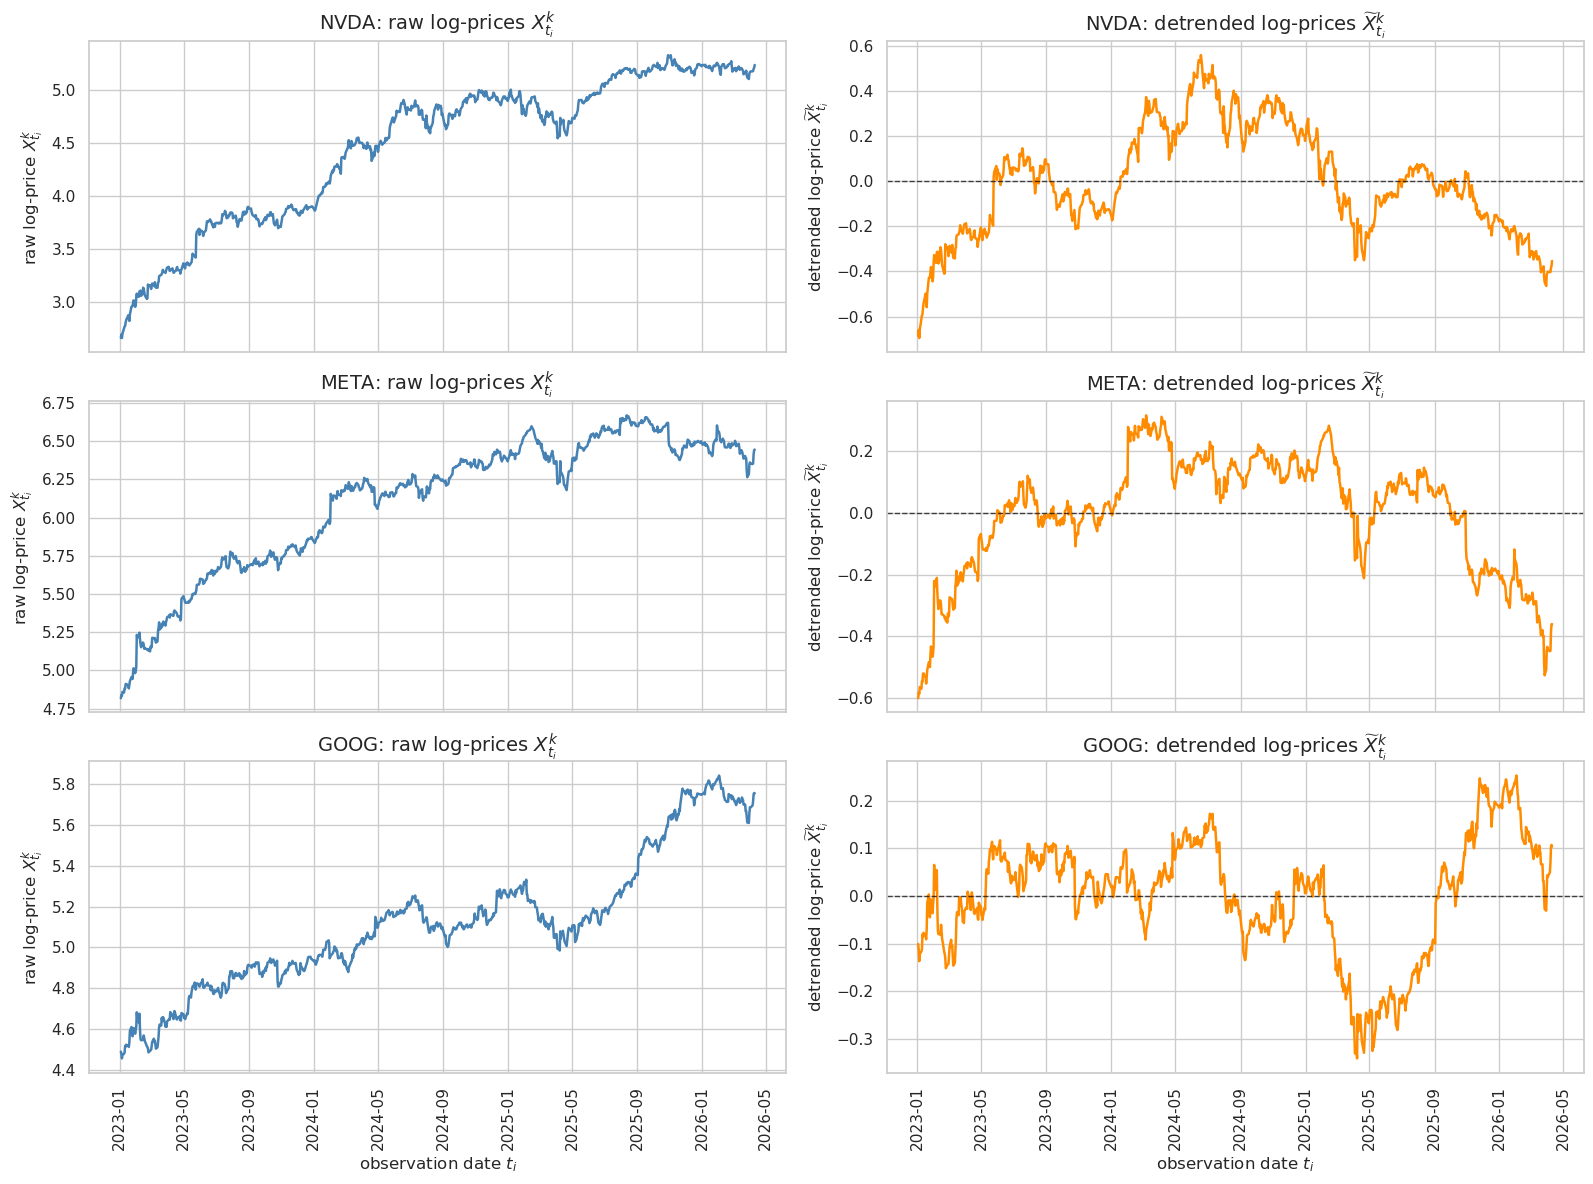

In [7]:
plot_raw_vs_detrended(  # Ставлю рядом raw и detrended levels, чтобы визуально увидеть эффект удаления линейного тренда.
    log_prices_df=log_prices_df,  # Слева показываю исходные log-prices.
    detrended_log_prices_df=detrended_log_prices_df,  # Справа показываю те же series после detrending.
    symbols=available_representatives,  # Ограничиваюсь representative stocks, чтобы график оставался читаемым.
)

## 7. Return distributions

<!-- Русский комментарий: здесь мы тоже повторяем формулы явно. Базовый ориентир — общая форма процесса Ито и его малых приращений. Если $dX_t = u\,dt + v\,dB_t$, то на маленьком шаге времени получаем приращение $\Delta X_t \approx u\,\Delta t + v\,\Delta B_t$, а если ещё помнить, что приращение броуновского движения имеет масштаб $\sqrt{\Delta t}$, то естественно возникает и формула через $\varepsilon_t$. Именно поэтому здесь разумно смотреть на распределения daily log-returns: они являются дискретным аналогом малых приращений процесса Ито. Формулы повторяются специально, чтобы теоретическая вставка из раздела 3 не оставалась висящей отдельно. Подписи на гистограммах тоже повторяют обозначения $\Delta X_{t_i}^k$ и $\Delta \widetilde{X}_{t_i}^k$, чтобы reader сразу видел, какая именно величина из формул показана на графике. См. `NOTEBOOK_FORMULA_RULES.md` и рус. перевод `TextBooks/Oxendal_B_Stokhasticheskie_differentsialnye_uravnenia.pdf`, теорема 4.1.2. -->

From the Itô-process viewpoint, the basic local model is

$$dX_t = u\,dt + v\,dB_t. \tag{4.1.6}$$

Over a small time step $\Delta t$, this suggests the increment approximation

$$\Delta X_t \approx u\,\Delta t + v\,\Delta B_t,$$

and since Brownian increments satisfy $\Delta B_t \approx \sqrt{\Delta t}\,\varepsilon_t$ with a standard-normal shock $\varepsilon_t$, one obtains the more explicit discrete picture

$$\Delta X_t \approx u\,\Delta t + v\sqrt{\Delta t}\,\varepsilon_t.$$

Daily log-returns are the empirical analogue of these one-step increments.

This section is not the main OU test. Its purpose is narrower: it checks what changes, and what does **not** change, when we move from raw log-returns to detrended log-returns.

Because detrending in this notebook is linear in time, detrended returns differ from raw returns mainly by a small constant shift equal to the estimated trend slope. Therefore, the two histograms are expected to have very similar spread and shape, while their centers move slightly closer to zero.

This matters for the narrative. Mean reversion is not expected to reveal itself dramatically in one-day return histograms; it is mainly a property of detrended **levels** and of their serial dependence.

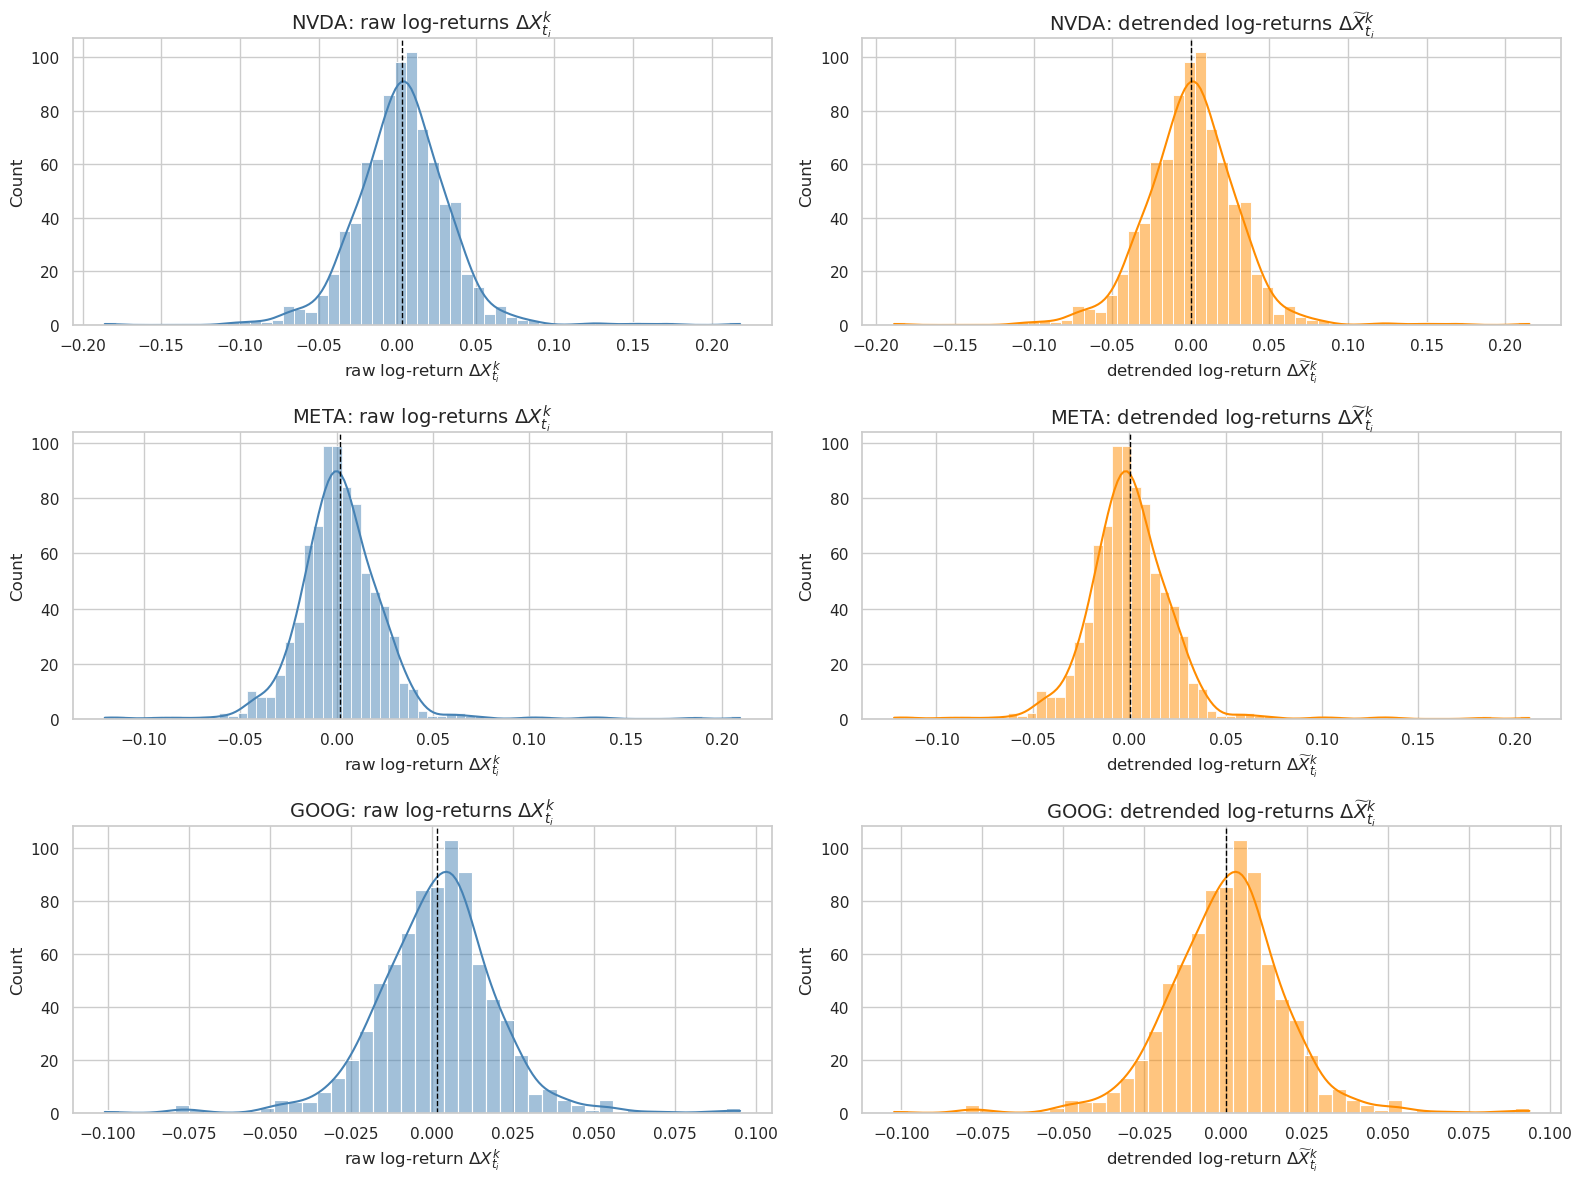

In [8]:
plot_return_distributions(  # Сравниваю гистограммы raw и detrended returns, чтобы увидеть, меняет ли detrending форму распределения.
    log_returns_df=log_returns_df,  # Беру исходные log-returns.
    detrended_returns_df=detrended_returns_df,  # Сравниваю их с returns после удаления линейного тренда из уровней.
    symbols=available_representatives,  # Смотрю только representative stocks, чтобы сравнение было наглядным.
)

### Distribution interpretation

<!-- Русский комментарий: эта ячейка интерпретирует гистограммы как проверку diffusion-style increment picture. Смысл в том, что detrending почти не меняет шумовую форму однодневных приращений, а в основном убирает deterministic trend component из уровней. -->

The main message of these histograms is that detrending changes the **center** of the return distribution much more than it changes the **shape**.

For the representative stocks, the raw and detrended return distributions have almost identical spread and asymmetry, while the sample means move closer to zero after detrending. In other words, detrending does **not** create OU-like behavior by reshaping daily shocks; it mainly removes the deterministic drift component from the level series.

This is why the OU discussion later focuses on detrended **levels** and their persistence, not on claiming that one-day returns suddenly become a different distribution.

## 8. Rolling diagnostics for raw log-returns

<!-- Русский комментарий: эта ячейка продолжает использовать формулу Ито уже не на уровне одной гистограммы, а на уровне локальной устойчивости параметров. Теперь формула повторяется явно. Если базовая модель имеет вид $dX_t = u\,dt + v\,dB_t$, то на малом шаге времени это даёт дискретное приращение $\Delta X_t \approx u\,\Delta t + v\,\Delta B_t \approx u\,\Delta t + v\sqrt{\Delta t}\,\varepsilon_t$. Именно поэтому ниже мы смотрим на rolling mean и rolling std для наблюдаемых raw log-returns $\Delta X_{t_i}^k$. Подписи на графиках повторяют это обозначение прямо в titles и y-labels, чтобы читатель видел, какая именно величина из формулы диагностируется. См. рус. перевод `TextBooks/Oxendal_B_Stokhasticheskie_differentsialnye_uravnenia.pdf`, теорема 4.1.2 и главы 3--5. -->

This section uses the same increment viewpoint more explicitly.

The local Itô benchmark is

$$dX_t = u\,dt + v\,dB_t. \tag{4.1.6}$$

Over a small time step $\Delta t$, this suggests the discrete approximation

$$\Delta X_t \approx u\,\Delta t + v\,\Delta B_t \approx u\,\Delta t + v\sqrt{\Delta t}\,\varepsilon_t.$$

So the empirical object diagnosed below is the observed raw log-return increment $\Delta X_{t_i}^k$.

The next plots show the **21-trading-day rolling mean** and the **21-trading-day rolling standard deviation** of these raw log-returns. In a textbook diffusion with constant coefficients, these curves would be relatively stable. In real equity data they move substantially, especially the volatility curve.

The graph titles and y-axis labels repeat the notation $\Delta X_{t_i}^k$ explicitly, so that the plotted statistics can be matched directly to the increment formula above.

So the point of the section is diagnostic rather than confirmatory. It shows where the simple diffusion intuition is useful and where the data visibly depart from a constant-parameter picture.

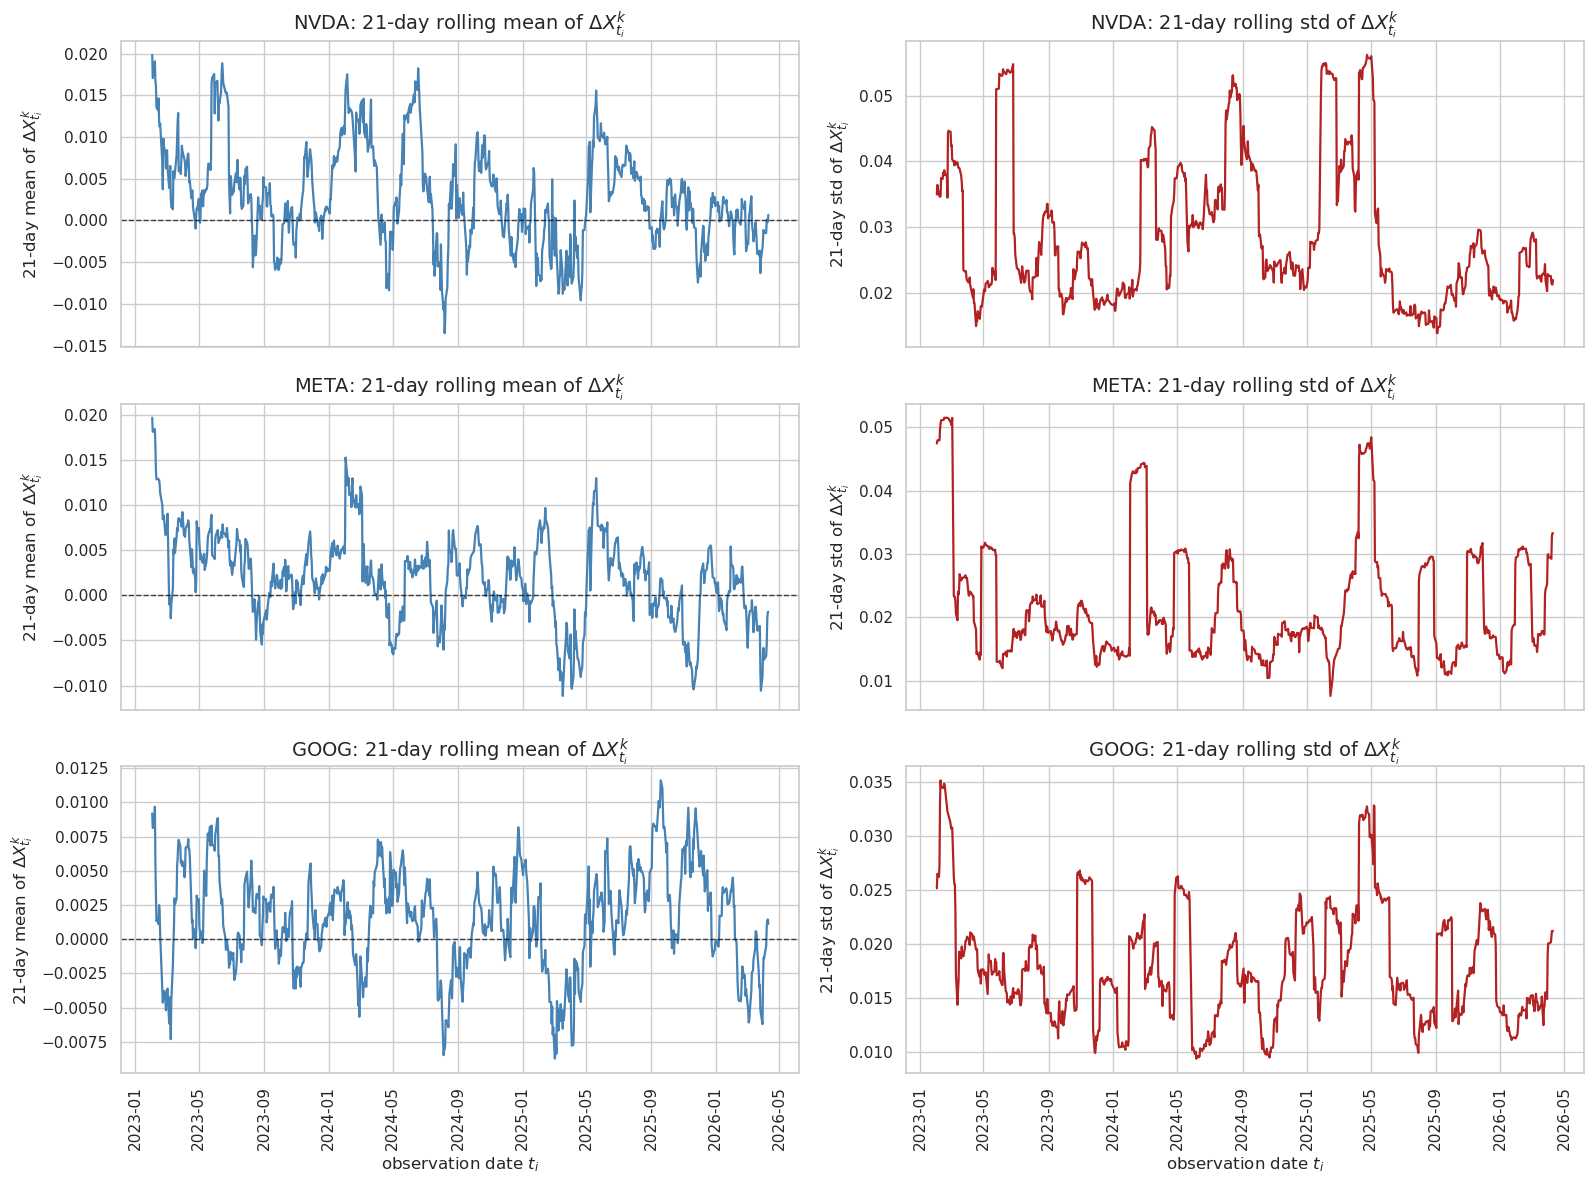

In [9]:
rolling_window = 21  # Беру окно примерно в один торговый месяц, чтобы локальная динамика была видна без чрезмерного шума.
plot_rolling_diagnostics(  # Строю rolling mean и rolling volatility для raw log-returns.
    log_returns_df=log_returns_df,  # Использую именно raw returns, потому что здесь обсуждается diffusion-style view of increments.
    symbols=available_representatives,  # Ограничиваюсь representative stocks для компактного сравнения.
    rolling_window=rolling_window,  # Передаю длину rolling-окна явно, чтобы её было видно в коде и на графиках.
)

### Rolling-diagnostic interpretation

<!-- Русский комментарий: эта ячейка проговаривает, что именно мы узнали о diffusion benchmark. Средние приращения остаются малыми, что согласуется с noisy-drift intuition, но volatility заметно нестационарна, поэтому простая SDE с постоянными коэффициентами оказывается только первым приближением. -->

The visual conclusion is asymmetric.

The rolling means fluctuate around zero and usually remain small relative to the volatility scale, which is broadly compatible with the idea that daily drift is hard to identify in noisy equity data. The rolling volatility, however, is clearly time-varying rather than constant.

In this sample, the 21-day rolling standard deviation moves roughly from `0.014` to `0.056` for `NVDA`, from `0.008` to `0.052` for `META`, and from `0.009` to `0.035` for `GOOG`. So a diffusion model with fixed coefficients is useful as a first teaching benchmark, but not as a literal description of the full time variation in market risk.

## 9. Autocorrelation of detrended levels

<!-- Русский комментарий: здесь notebook переключается с diffusion-style increments на mean-reverting levels. Формула из упр. 5.7 про средне-возвратный OU-процесс должна проявляться не в форме гистограммы однодневных returns, а в том, что уровни после detrending сохраняют заметную зависимость на малых лагах и затем постепенно “забывают” прошлое. См. рус. перевод `TextBooks/Oxendal_B_Stokhasticheskie_differentsialnye_uravnenia.pdf`, упр. 5.7: средне-возвратный процесс Орнштейна—Уленбека. -->

This section now switches from diffusion-style increments to mean-reverting levels.

The OU reference equation **(5.7)** describes a process pulled back toward a mean level rather than a pure random walk. In discrete data this should show up as positive short-lag dependence in levels with gradual decay over larger lags.

The next output has two parts. First, the line plot shows how autocorrelation decays with lag. Second, the table reports the same values numerically for lags 1 to 20.

This does **not** prove that the data follow an exact OU law. However, it does provide an empirical signature consistent with OU-style persistence in detrended levels.

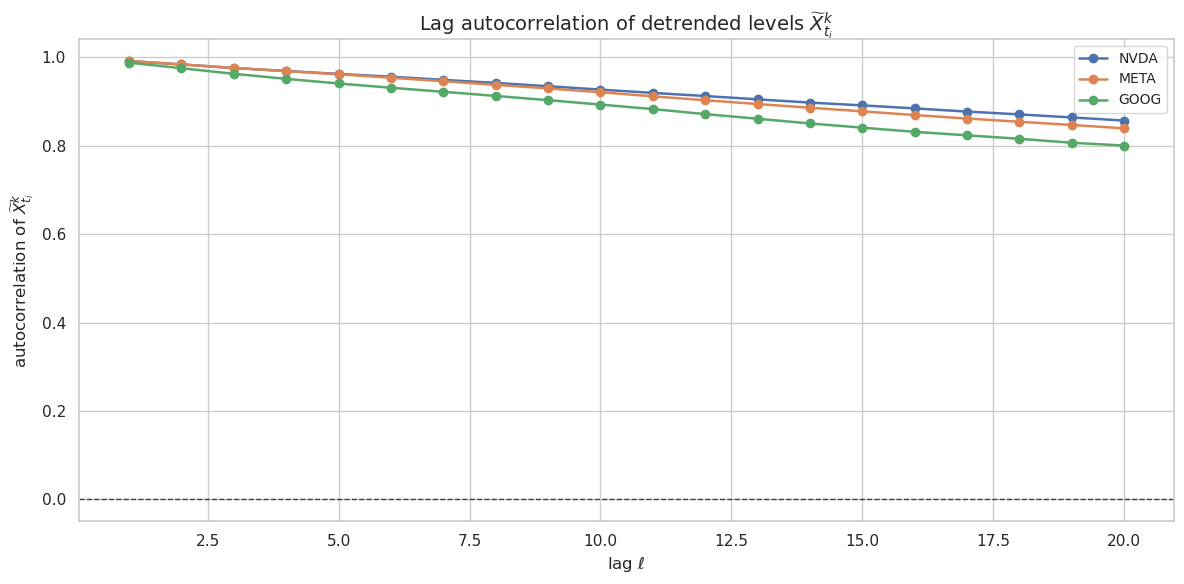

,NVDA,META,GOOG
1,0.9916,0.9919,0.9880
2,0.9840,0.9840,0.9754
3,0.9758,0.9762,0.9628
4,0.9691,0.9688,0.9513
5,0.9626,0.9617,0.9409
6,0.9562,0.9539,0.9312
7,0.9491,0.9460,0.9221
8,0.9421,0.9378,0.9128
9,0.9347,0.9297,0.9032
10,0.9270,0.9210,0.8931


In [10]:
autocorrelation_df = compute_autocorrelation_table(  # Считаю автокорреляции detrended levels по лагам для representative stocks.
    detrended_log_prices_df=detrended_log_prices_df,  # Использую detrended levels как основной объект OU-интерпретации.
    symbols=available_representatives,  # Смотрю только на выбранные representative stocks.
    max_lag=20,  # Беру первые 20 лагов, чтобы увидеть начальную скорость затухания зависимости.
)

plot_autocorrelation_table(autocorrelation_df)  # Сначала визуально смотрю на форму убывания автокорреляции.
autocorrelation_df.round(4)  # Затем печатаю те же значения таблицей, чтобы можно было ссылаться на конкретные лаги.

### Autocorrelation interpretation

<!-- Русский комментарий: эта ячейка переводит график автокорреляции на язык mean reversion. Именно плавное затухание положительной автокорреляции делает связь с OU-style dynamics содержательной, а не только визуальной. -->

The plot and table show the pattern we were looking for: high positive short-lag autocorrelation with gradual decay.

For the representative stocks, lag-1 autocorrelation is about `0.9916` for `NVDA`, `0.9919` for `META`, and `0.9880` for `GOOG`, and the correlations then decline step by step rather than collapsing to zero immediately. This is consistent with persistent, slowly mean-reverting detrended levels.

Again, this does not prove an exact OU law. But it is a clear empirical signature that supports the later OU-style half-life estimates of roughly `56-57` trading days.

## 10. Simple OU-style parameter intuition

<!-- Русский комментарий: эта ячейка делает следующий логический шаг после упр. 5.7 из Øksendal: от качественной mean-reversion picture к простой параметрической аппроксимации. Здесь я явно связываю continuous-time OU equation с дискретной AR(1)-регрессией, потому что именно так notebook получает числа вроде $\hat{\phi}$, $\hat{\theta}$ и half-life. См. рус. перевод `TextBooks/Oxendal_B_Stokhasticheskie_differentsialnye_uravnenia.pdf`, упр. 5.7 и пример 12.3.5. -->

The textbook mean-reverting OU reference point used in this notebook is

$$dX_t = (m - X_t)\,dt + u\,dB_t. \tag{5.7}$$

For empirical work it is convenient to write the same idea with an explicit speed parameter $\theta > 0$ as $dX_t = \theta(m - X_t)\,dt + u\,dB_t$.

Over one trading-day step this continuous-time model suggests a first-order discrete approximation $X_{t+1} \approx \alpha + \phi X_t + \varepsilon_{t+1}$, where $\phi \approx e^{-\theta}$ and $\alpha \approx m(1 - \phi)$ in the OU-style interpretation.

The key empirical quantity is the persistence coefficient `phi_hat`, that is, $\hat{\phi}$: values below $1$ suggest pullback toward a long-run level rather than a pure random walk in levels.

This is only an **educational approximation**. It is not a full econometric calibration of an OU diffusion. Its purpose is to connect the detrended empirical series with a familiar mean-reversion parameterization.

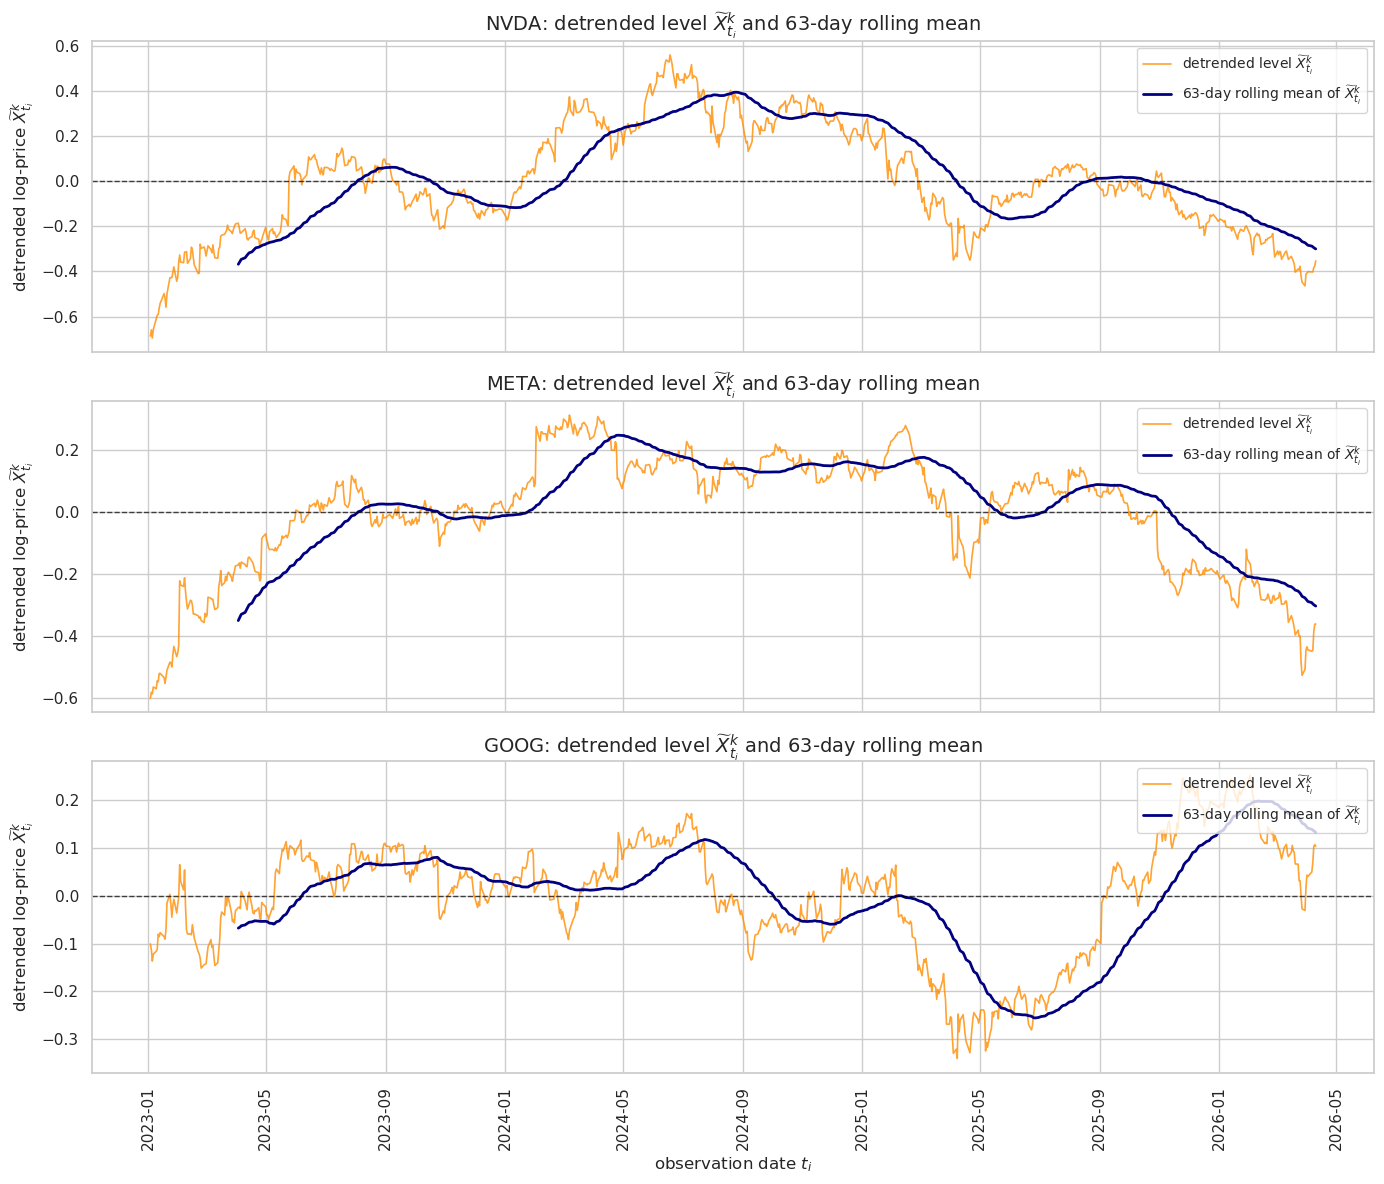

In [11]:
plot_detrended_levels_with_rolling_mean(  # Показываю detrended levels вместе с более медленным rolling mean, чтобы увидеть локальные отклонения вокруг нуля.
    detrended_log_prices_df=detrended_log_prices_df,  # Использую detrended levels как основной объект mean-reversion анализа.
    symbols=available_representatives,  # Смотрю на те же representative stocks, что и раньше.
    window=63,  # Беру окно примерно в квартал, чтобы сгладить краткосрочный шум.
)

### What the OU-style parameter table means

<!-- Русский комментарий: эта ячейка нужна как подробный мост между continuous-time OU equation и теми столбцами, которые потом появляются в таблице. Без этого таблица с `alpha_hat`, `phi_hat`, `theta_hat` и `half_life_days` выглядит как набор “чисел из кода”, а не как осмысленное продолжение формулы из упр. 5.7. -->

Before printing the parameter table, recall the bridge used by the code.

Starting from the OU-style equation $dX_t = \theta(m - X_t)\,dt + u\,dB_t$, the notebook estimates its one-step discrete proxy $\widetilde{X}_t \approx \hat{\alpha} + \hat{\phi}\widetilde{X}_{t-1} + \varepsilon_t$.

The reported columns mean the following:

- `alpha_hat` ($\hat{\alpha}$): the estimated intercept in the one-step regression.
- `phi_hat` ($\hat{\phi}$): the estimated persistence coefficient; values close to $1$ indicate slow decay of shocks.
- `theta_hat` ($\hat{\theta} = -\ln(\hat{\phi})$ when $0 < \hat{\phi} < 1$): the implied discrete-to-continuous mean-reversion speed.
- `half_life_days` ($\ln(2) / \hat{\theta}$): the implied time needed for a deviation to shrink by half.
- `long_run_mean_hat` ($\hat{\alpha} / (1 - \hat{\phi})$): the implied long-run mean level in the AR(1)/OU-style approximation.
- `sigma_hat`: the sample standard deviation of the regression residuals $\varepsilon_t$.

So this table is not a direct textbook OU calibration. It is a simple bridge from detrended empirical levels to an OU-style interpretation of persistence, mean reversion speed, and half-life.

In [12]:
ou_parameter_df = fit_simple_ou_parameters(  # Оцениваю простые AR(1)-style параметры, которые интерпретирую в духе OU.
    detrended_log_prices_df=detrended_log_prices_df,  # Подаю detrended levels, потому что именно для них обсуждается mean reversion.
    symbols=available_representatives,  # Считаю оценки только для representative stocks.
)

ou_parameter_df.round(4)  # Печатаю компактную таблицу оценённых коэффициентов и implied half-life.

,symbol,alpha_hat,phi_hat,theta_hat,half_life_days,long_run_mean_hat,sigma_hat
0,NVDA,0.0004,0.9878,0.0123,56.3957,0.0337,0.0305
1,META,0.0003,0.9879,0.0122,56.7781,0.0245,0.0236
2,GOOG,0.0002,0.9880,0.0121,57.4022,0.0207,0.0187


## 11. Simulation section

<!-- Русский комментарий: этот раздел замыкает логическую цепочку, чтобы формулы из `Short mathematical background` больше не казались изолированными. Теперь те же самые SDE записываются ещё раз уже как явные benchmark-модели, по которым мы строим simulated paths и сравниваем их с эмпирическими рядами. См. рус. перевод `TextBooks/Oxendal_B_Stokhasticheskie_differentsialnye_uravnenia.pdf`, §2.2, гл. 5.1, упр. 5.7, пример 12.3.5. -->

The simulation block now reuses the same formulas introduced earlier in Section 3.

- **Brownian motion** provides the basic noise source $B_t$ from **Chapter 2.2**.
- **Geometric Brownian motion** uses $dN_t = rN_t\,dt + \alpha N_t\,dB_t$ from **(5.1.3)**, with solution **(5.1.5)**.
- **Ornstein-Uhlenbeck dynamics** use $dX_t = (m - X_t)\,dt + u\,dB_t$ from **Exercise 5.7**.

This section therefore closes the logical loop: the formulas first introduced in the mathematical background are now used again as explicit benchmark models for simulated paths and empirical comparison.

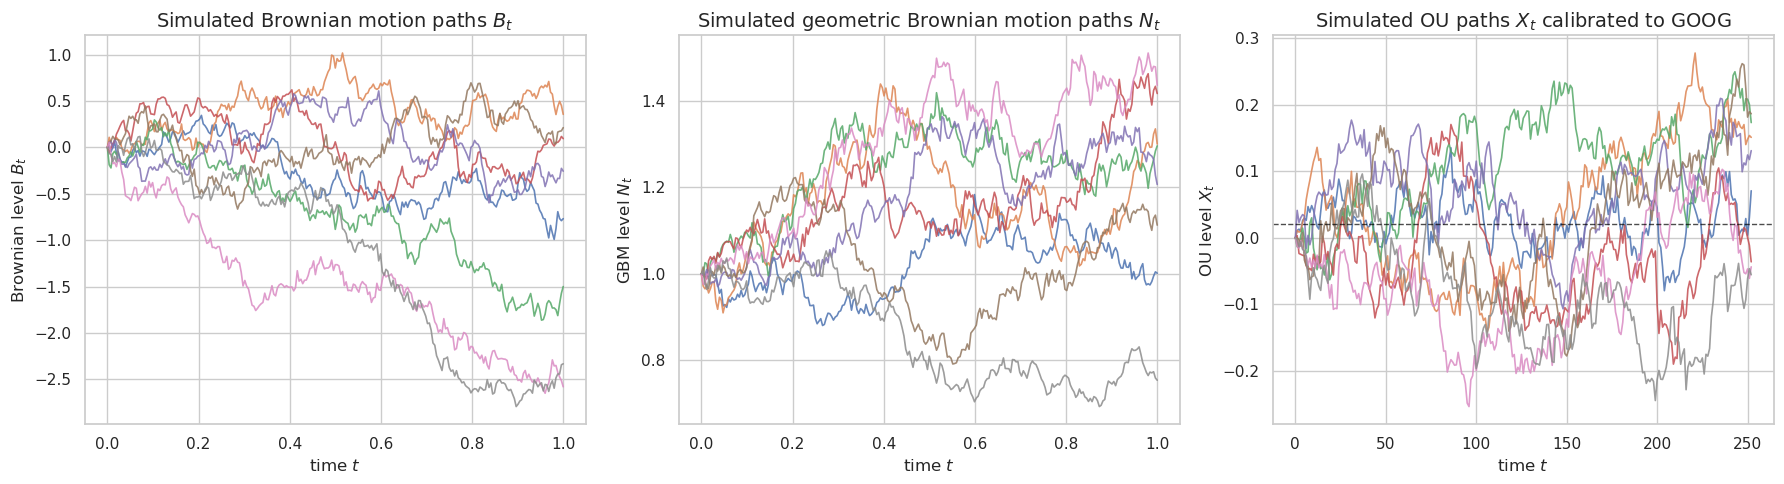

In [13]:
rng = np.random.default_rng(42)  # Фиксирую seed, чтобы симуляции были воспроизводимыми.

brownian_time, brownian_paths = simulate_brownian_paths(  # Генерирую эталонные траектории стандартного броуновского движения.
    n_paths=8,
    n_steps=252,
    dt=1.0 / 252.0,
    rng=rng,
)

gbm_time, gbm_paths = simulate_gbm_paths(  # Генерирую траектории geometric Brownian motion с умеренным drift и volatility.
    n_paths=8,
    n_steps=252,
    dt=1.0 / 252.0,
    x0=1.0,
    drift=0.12,
    volatility=0.25,
    rng=rng,
)

ou_reference_symbol = "GOOG" if "GOOG" in set(ou_parameter_df["symbol"]) else available_representatives[0]  # Беру GOOG как основной OU-пример, а если его нет, использую первый доступный representative symbol.
ou_reference_row = ou_parameter_df.loc[ou_parameter_df["symbol"] == ou_reference_symbol].iloc[0]  # Достаю строку с оценёнными OU-параметрами для выбранного тикера.
ou_theta = float(ou_reference_row["theta_hat"])  # Извлекаю скорость mean reversion.
ou_mean_level = float(ou_reference_row["long_run_mean_hat"])  # Извлекаю оценённый long-run mean.
ou_sigma_discrete = float(ou_reference_row["sigma_hat"])  # Беру дискретную оценку масштаба инноваций.
ou_diffusion_scale = discrete_residual_std_to_ou_diffusion_scale(  # Перевожу дискретный шум в continuous-time OU diffusion scale.
    theta_hat=ou_theta,
    sigma_hat=ou_sigma_discrete,
    dt=1.0,
)

ou_time, ou_paths = simulate_ou_paths(  # Симулирую OU-пути с параметрами, калиброванными по выбранному representative stock.
    n_paths=8,
    n_steps=252,
    dt=1.0,
    x0=0.0,
    theta=ou_theta,
    mean_level=ou_mean_level,
    diffusion_scale=ou_diffusion_scale,
    rng=rng,
)

plot_simulated_model_paths(  # Показываю рядом Brownian, GBM и OU, чтобы визуально сравнить три классических режима динамики.
    brownian_time=brownian_time,
    brownian_paths=brownian_paths,
    gbm_time=gbm_time,
    gbm_paths=gbm_paths,
    ou_time=ou_time,
    ou_paths=ou_paths,
    ou_mean_level=ou_mean_level,
    ou_reference_symbol=ou_reference_symbol,
)

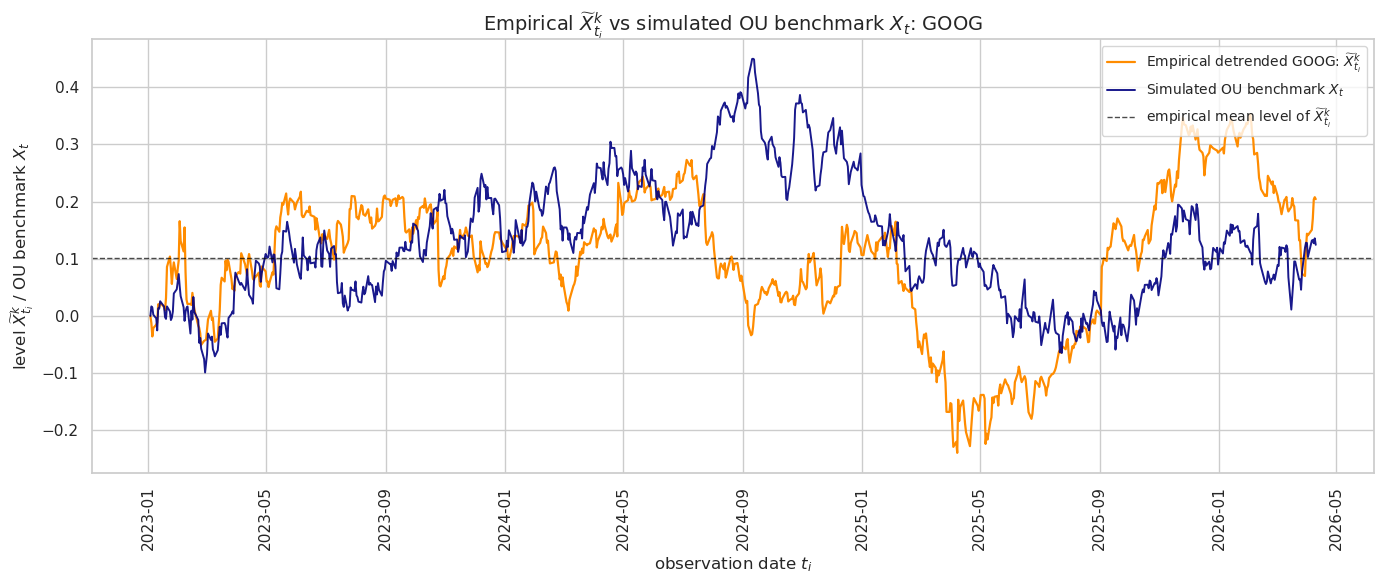

In [14]:
comparison_symbol = ou_reference_symbol  # Для прямого сравнения беру тот же тикер, по которому калибровал OU benchmark.
empirical_rescaled = detrended_log_prices_df[comparison_symbol].dropna()  # Извлекаю эмпирическую detrended series без пропусков.
empirical_rescaled = empirical_rescaled - empirical_rescaled.iloc[0]  # Сдвигаю series так, чтобы стартовая точка была нулевой и сравнение было честнее визуально.

_, comparison_ou_paths = simulate_ou_paths(  # Генерирую одну OU-траекторию той же длины, что и эмпирическая series.
    n_paths=1,
    n_steps=len(empirical_rescaled) - 1,
    dt=1.0,
    x0=float(empirical_rescaled.iloc[0]),
    theta=ou_theta,
    mean_level=float(empirical_rescaled.mean()),
    diffusion_scale=ou_diffusion_scale,
    rng=rng,
)
comparison_ou_series = pd.Series(comparison_ou_paths[0], index=empirical_rescaled.index)  # Превращаю симуляцию в Series с тем же временным индексом.

plot_empirical_vs_simulated_ou(  # Ставлю рядом эмпирическую detrended path и одну OU benchmark simulation.
    empirical_series=empirical_rescaled,
    simulated_series=comparison_ou_series,
    symbol=comparison_symbol,
)

### Simulation interpretation

<!-- Русский комментарий: эта ячейка проговаривает, что именно визуализируют только что использованные формулы. Левый блок — базовый броуновский шум, средний — GBM growth model из гл. 5.1, правый — mean-reverting OU benchmark из упр. 5.7. -->

The left panel visualizes the basic Brownian noise source from Section 3. The middle panel visualizes the growth model **(5.1.3)**-**(5.1.5)**. The right panel visualizes the mean-reverting benchmark **(5.7)**.

This is exactly why the notebook separates raw and detrended data: raw log-prices are visually closer to a drift-dominated growth picture, while detrended levels are more naturally compared with a mean-reverting OU benchmark.

## 12. Optional animations

<!-- Русский комментарий: эта ячейка поясняет, что GIF-анимации не вводят новые модели, а лишь делают уже обсуждённые benchmark-SDE более наглядными. Анимации продолжают ту же логику, что и предыдущий simulation section, но в более “живом” формате. -->

The GIF generation logic is kept in `notebook_support.py` so that the notebook remains presentation-friendly.

Each colored line in the GIFs denotes one independently simulated path of the corresponding model. In the OU animation, the dashed horizontal line marks the estimated long-run mean.

If `regenerate_animation_assets = True`, the helper module rebuilds the files in `animation_outputs/`. Otherwise, the notebook simply loads the GIFs that are already stored on disk.

brownian: animation_outputs/brownian_motion.gif
Brownian GIF: each colored line is one independently simulated Brownian path $B_t$.


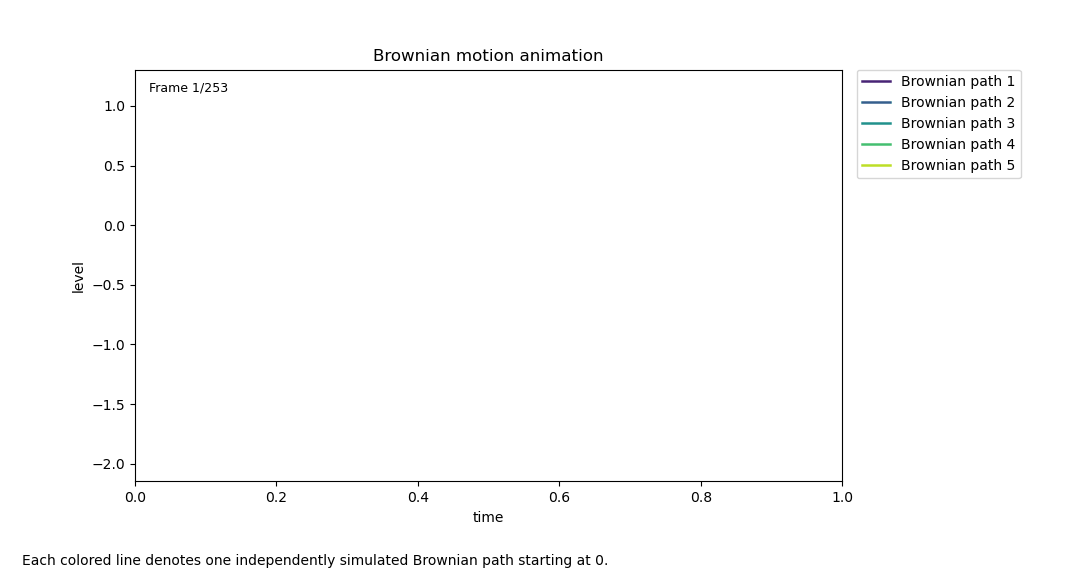

ou: animation_outputs/ou_process.gif
OU GIF: each colored line is one independently simulated OU path $X_t$; the dashed line is the estimated long-run mean $\hat{m}$.


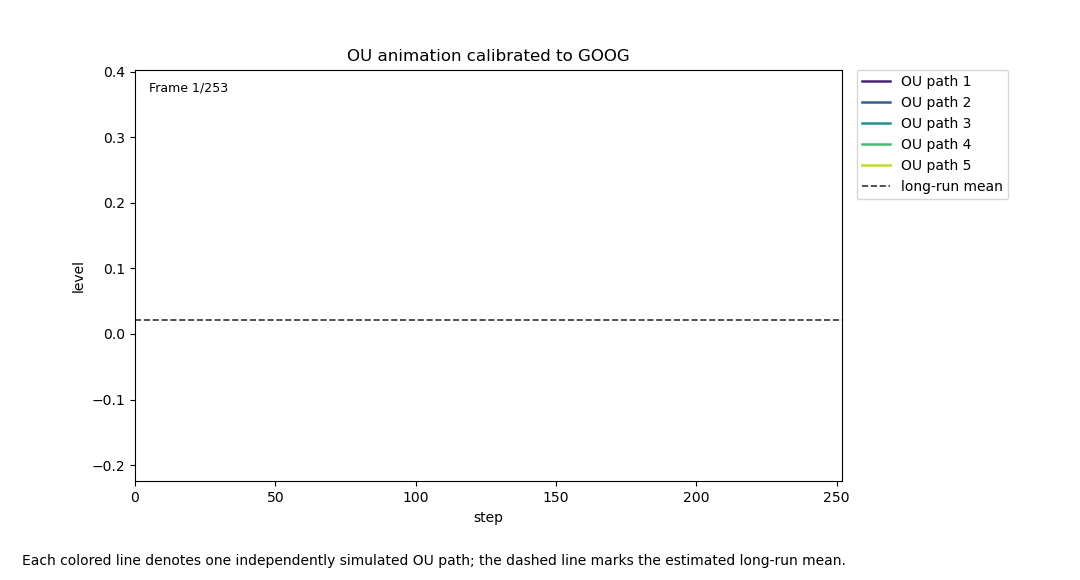

In [15]:
regenerate_animation_assets = False  # По умолчанию не пересобираю GIF, а использую уже сохранённые файлы с диска.
animation_paths = ensure_animation_assets(  # Проверяю наличие animation assets и при необходимости создаю их.
    brownian_time=brownian_time,
    brownian_paths=brownian_paths,
    ou_time=ou_time,
    ou_paths=ou_paths,
    ou_mean_level=ou_mean_level,
    ou_reference_symbol=ou_reference_symbol,
    regenerate=regenerate_animation_assets,
)

display_available_animations(animation_paths)  # Показываю доступные GIF-файлы прямо в ноутбуке.

## 13. Model assessment criterion

<!-- Русский комментарий: этот раздел добавлен после замечания профессора Ibrahim Fatkullin. Главная правка методологии: теперь слово compatible/fits не означает "мне визуально нравится график". Оно означает, что модель сначала подгоняется по явно названным статистикам, а затем проверяется по другим диагностическим величинам. Для OU параметры берутся из one-step AR(1), а затем проверяется decay автокорреляции и простая transition-style conditional mean. Это не полноценный likelihood-test и не строгая проверка Markov transition kernel, но уже задаёт систематический критерий, которого раньше не хватало. -->

The word **compatible** is used here in a concrete diagnostic sense, not as a purely visual judgment.

The assessment workflow is:

1. **Fit a small number of parameters** using one simple statistic or regression.
2. **Check additional implications** of the fitted model that were not used directly as the fitting target.
3. **Report visible failures** instead of forcing one SDE to explain every feature of the data.

For the OU-style part, the fit uses the one-step AR(1) proxy for detrended levels,

$$\widetilde{X}_{t+1} \approx \hat{\alpha} + \hat{\phi}\widetilde{X}_t + \varepsilon_{t+1}.$$

Then the fitted $\hat{\phi}$ is validated in two additional ways:

- the empirical autocorrelation decay for lags $2,\ldots,20$ is compared with the OU/AR(1) implication $\hat{\phi}^{\ell}$;
- a simple transition-style check compares binned empirical conditional means of $\widetilde{X}_{t+5}$ with the AR(1) forecast $\hat{m} + \hat{\phi}^5(\widetilde{X}_t - \hat{m})$.

For the diffusion / GBM-style part, the notebook uses trend strength in raw log-prices and rolling-volatility instability in raw returns as diagnostic criteria. This keeps the project educational, but it gives a clear answer to the question: **what does it mean for a benchmark SDE to fit the data?**


In [16]:
sde_quantitative_summary_df = build_sde_quantitative_summary(  # Считаю компактный численный ответ на вопрос “насколько” работают SDE-benchmark модели.
    log_prices_df=log_prices_df,
    detrended_log_prices_df=detrended_log_prices_df,
    log_returns_df=log_returns_df,
    ou_parameter_df=ou_parameter_df,
    symbols=available_representatives,
)

ou_validation_diagnostics_df = build_ou_validation_diagnostics(  # Проверяю OU-fit по автокорреляциям и transition-style conditional mean.
    detrended_log_prices_df=detrended_log_prices_df,
    ou_parameter_df=ou_parameter_df,
    symbols=available_representatives,
    max_acf_lag=20,
    transition_horizon=5,
    n_transition_bins=5,
)

model_assessment_df = sde_quantitative_summary_df.merge(  # Соединяю fit-метрики и validation-метрики в одну таблицу.
    ou_validation_diagnostics_df,
    on="symbol",
    how="left",
)

model_assessment_df[[  # Показываю только главные критерии, чтобы таблица читалась как summary slide.
    "symbol",
    "raw_trend_r2",
    "ou_ar1_r2",
    "half_life_days",
    "rolling_vol_ratio",
    "acf_decay_rmse_lags_2_20",
    "transition_mean_rmse_h5",
    "transition_z_std_h5",
]].round(4)


,symbol,raw_trend_r2,ou_ar1_r2,half_life_days,rolling_vol_ratio,acf_decay_rmse_lags_2_20,transition_mean_rmse_h5,transition_z_std_h5
0,NVDA,0.8833,0.9832,56.3957,4.0594,0.0489,0.0055,0.9410
1,META,0.8220,0.9838,56.7781,6.7957,0.0381,0.0052,0.9673
2,GOOG,0.8663,0.9761,57.4022,3.7393,0.0071,0.0069,1.0028


## 14. Main findings

<!-- Русский комментарий: финальный численный вывод теперь опирается на явные criteria. Сначала raw_trend_r2 показывает, насколько raw log-prices согласуются с drift-dominated/GBM-style growth picture. Затем ou_ar1_r2 показывает качество one-step OU/AR(1) fit. После этого acf_decay_rmse_lags_2_20 и transition_mean_rmse_h5 проверяют дополнительные следствия fitted OU proxy, которые не являются просто повторением той же one-step регрессии. rolling_vol_ratio показывает слабое место простой constant-volatility diffusion. -->

The table above is the compact numerical answer to the model-assessment question.

The main answer is not a single universal goodness-of-fit number. The approximation quality depends on which empirical object is being modeled and which diagnostic implication is being checked.

The main empirical conclusions are:

1. Raw log-prices are strongly trend-dominated, so they are more naturally interpreted through a drift-dominated diffusion / GBM-style growth benchmark than through an OU benchmark.
2. Detrended levels have strong one-step persistence, which supports the OU-style AR(1) approximation and produces interpretable half-life estimates.
3. The OU-style interpretation is more credible when the same fitted $\hat{\phi}$ also gives a reasonable autocorrelation-decay diagnostic and a reasonable transition-style conditional-mean diagnostic.
4. Daily log-returns are the natural empirical increments for diffusion-style diagnostics, but their rolling volatility is visibly time-varying, so a constant-parameter diffusion is only a first approximation.

Therefore, the central answer is qualified:

> Simple textbook SDEs describe some aspects of the data well as benchmarks: raw log-prices are compatible with a GBM-style growth picture, and detrended levels are compatible with a slow OU-style persistence picture under explicit diagnostics. But a single constant-parameter SDE does not describe the full equity process, especially because return volatility changes substantially over time.


## 15. Limitations

<!-- Русский комментарий: эта ячейка нужна, чтобы не переобещать точность модели. После добавления model assessment criterion важно прямо сказать, что новая transition-style проверка является только простой проверкой условного среднего, а не полным тестом transition kernel или likelihood-based model comparison. -->

This notebook is intentionally a small educational mini research project, so several limitations should be stated explicitly.

The quantitative assessment in Section 13 is diagnostic: it measures trend strength, one-step AR(1) persistence, half-life, autocorrelation-decay error, a binned transition-style conditional-mean error, and rolling-volatility instability. It is **not** a formal likelihood-based SDE model comparison.

- The analysis uses daily data only.
- Detrending is linear and intentionally simple.
- The OU interpretation is educational rather than fully econometric.
- The transition-style diagnostic checks only conditional means, not the full transition kernel.
- The representative stocks are chosen for readability and illustration, not for exhaustive cross-sectional inference.
- The simulation section is designed for intuition, not for formal model testing.


## 16. Conclusion

<!-- Русский комментарий: финальная ячейка теперь отвечает на основной вопрос исследования через criteria, а не через визуальную фразу "подходит". Вывод: SDE-подход частично работает как benchmark-language, но разные трансформации данных тяготеют к разным textbook-моделям, и ни одна простая SDE не даёт полного точного описания. -->

The main conclusion of this mini-research is qualified rather than absolute.

Stock-market time series **can** be described in the language of stochastic differential equations to a meaningful extent, but the description is approximate and depends strongly on which empirical object is being modeled. Raw levels look closer to a drift-dominated diffusion or GBM-style growth picture, whereas detrended levels look more compatible with slow OU-style mean reversion.

The key methodological change is that compatibility is now tied to explicit diagnostics: trend strength, one-step persistence, autocorrelation decay, transition-style conditional means, and volatility stability. This makes the conclusion more systematic than a visual comparison of plots.

At the same time, the notebook also shows the limits of this approach. A single low-dimensional SDE does not reproduce every visible feature of the data: volatility is time-varying, model fit is transformation-dependent, and the OU calibration here is only a simple educational proxy.

For a student mini research project, this is already a useful answer to the central question. Simple textbook SDEs do not describe the market perfectly, but they provide a coherent and interpretable benchmark language for discussing growth, noise, persistence, and mean reversion in real equity data.

This leaves several natural directions for continuation:

- diffusion diagnostics across time aggregation, including variance scaling, weak serial dependence, and approximate Gaussianity;
- realized quadratic variation analysis;
- PCA-based market-factor extraction;
- OU analysis of a detrended factor;
- sparse-jump extensions;
- a more explicit link from fitted SDE baselines to generators and Fokker-Planck dynamics.
